In [12]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import KBinsDiscretizer

# Iris 데이터셋 로드
iris = sns.load_dataset('iris')

# 연속형 데이터를 범주형 데이터로 변환
discretizer = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
iris_binned = discretizer.fit_transform(iris.iloc[:, :-1])

# 범주형 데이터프레임 생성
iris_binned_df = pd.DataFrame(iris_binned, columns=iris.columns[:-1])
iris_binned_df['species'] = iris['species']

# 범주형 데이터 출력
print(iris_binned_df.head())


In [19]:
# 교차표 생성 (sepal_length)
contingency_table = pd.crosstab(index=iris_binned_df['species'], 
                                columns=iris_binned_df['sepal_length'])

# 교차표 출력
print(contingency_table)


sepal_length  0.0  1.0  2.0
species                    
setosa         45    5    0
versicolor      6   38    6
virginica       1   27   22


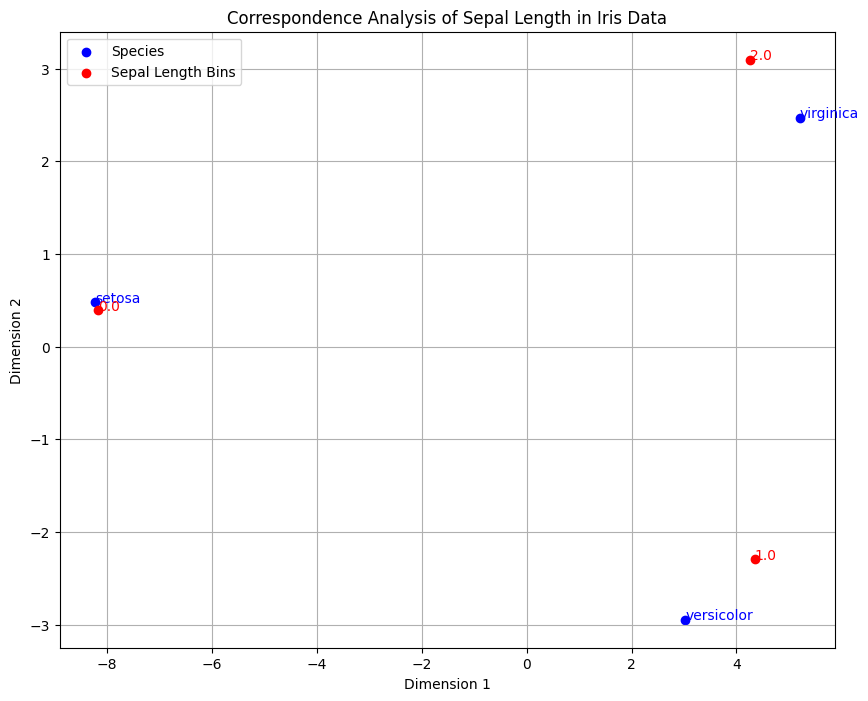

In [20]:
from scipy.stats import chi2_contingency
import numpy as np
import matplotlib.pyplot as plt

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Calculate residuals
residuals = (contingency_table.values - expected) / np.sqrt(expected)

# Singular Value Decomposition (SVD)
u, s, vt = np.linalg.svd(residuals)

# Principal coordinates
row_coords = u * s
col_coords = vt.T * s

# Plotting
plt.figure(figsize=(10, 8))
plt.scatter(row_coords[:, 0], row_coords[:, 1], color='blue', label='Species')
plt.scatter(col_coords[:, 0], col_coords[:, 1], color='red', label='Sepal Length Bins')

# Adding labels for rows
for i, label in enumerate(contingency_table.index):
    plt.text(row_coords[i, 0], row_coords[i, 1], label, color='blue')

# Adding labels for columns
for i, label in enumerate(contingency_table.columns):
    plt.text(col_coords[i, 0], col_coords[i, 1], label, color='red')

plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()
plt.title('Correspondence Analysis of Sepal Length in Iris Data')
plt.grid()
plt.show()